In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_data(filename):  # 载入数据
    xys = []
    with open(filename, 'r') as f:
        for line in f:
            xys.append(map(float, line.strip().split()))
        xs, ys = zip(*xys)
        return np.asarray(xs), np.asarray(ys)


def multinomial_basis(x, feature_num=10):
    x = np.expand_dims(x, axis=1)  # shape(N, 1)
    feat = [x]
    for i in range(2, feature_num + 1):
        feat.append(x ** i)
    ret = np.concatenate(feat, axis=1)
    return ret


def main(x_train, y_train):  # 训练模型，并返回从x到y的映射。
    basis_func = multinomial_basis  # shape(N, 1)的函数
    phi0 = np.expand_dims(np.ones_like(x_train), axis=1)  # shape(N,1)大小的全1 array
    phi1 = basis_func(x_train)  # 将x_train的shape转换为(N, 1)
    phi = np.concatenate([phi0, phi1], axis=1)  # phi.shape=(300,2) phi是增广特征向量的转置
    print("phi shape = ", phi.shape)
    # 使用最小二乘法优化w 
    w = np.dot(np.linalg.pinv(phi), y_train)  # np.linalg.pinv(phi)求phi的伪逆矩阵(phi不是列满秩) w.shape=[2,1]
    print("参数 w = ", w)

    def f(x):
        phi0 = np.expand_dims(np.ones_like(x), axis=1)
        phi1 = basis_func(x)
        phi = np.concatenate([phi0, phi1], axis=1)
        y = np.dot(phi, w)  # 矩阵乘法
        return y

    return f


def evaluate(ys, ys_pred):  # 评估模型
    std = np.sqrt(np.mean(np.abs(ys - ys_pred) ** 2))
    return std

x_train shape: (300,)
x_test shape: (200,)
phi shape =  (300, 11)
参数 w =  [-2.55764849e+00  1.55236293e+01 -1.10794277e+01  3.24334951e+00
 -4.39931138e-01  2.34928259e-02  7.76435566e-04 -1.76444460e-04
  9.84839960e-06 -2.49600724e-07  2.46515357e-09]
训练集 预测值与真实值的标准差：1.5
测试集 预测值与真实值的标准差：1.6


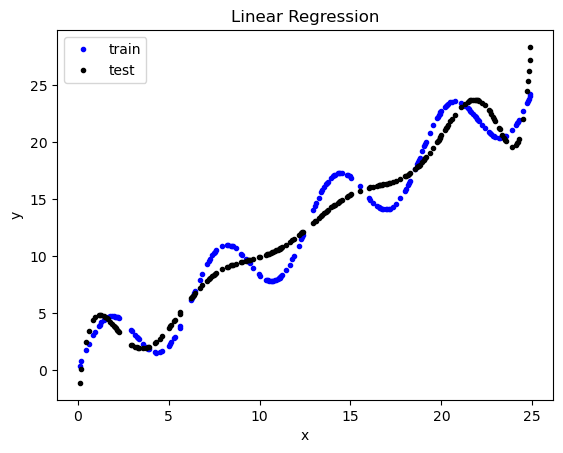

In [3]:
if __name__ == '__main__':  # 程序主入口（建议不要改动以下函数的接口）
    train_file = 'train.txt'
    test_file = 'test.txt'
    # 载入数据
    x_train, y_train = load_data(train_file)
    x_test, y_test = load_data(test_file)
    print("x_train shape:", x_train.shape)
    print("x_test shape:", x_test.shape)

    # 训练模型，返回一个函数f()使得 y = f(x)
    f = main(x_train, y_train)

    y_train_pred = f(x_train)  # 训练集 预测值
    std = evaluate(y_train, y_train_pred) # 使用训练集评估模型
    print('训练集 预测值与真实值的标准差：{:.1f}'.format(std))

    y_test_pred = f(x_test)  # 测试集 预测值
    std = evaluate(y_test, y_test_pred)  # 使用测试集评估模型
    print('测试集 预测值与真实值的标准差：{:.1f}'.format(std))

    # 显示结果
    # plt.plot(x_train, y_train, 'r.')  # 训练集
    plt.plot(x_test, y_test, 'b.')  # 测试集
    plt.plot(x_test, y_test_pred, 'k.')  # 测试集 的 预测值
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Linear Regression')
    plt.legend(['train', 'test', 'pred'])
    plt.show()